# teacher(PMRiskViT) 학습 - `pm_safeline`

로드뷰 이미지 -> 사고 위험도 teacher 모델(ViT) 학습 노트북(PROJECT.md §4.4~§4.5).

- 데이터: `datasets.roadview.make_train_valid` (manifest.csv 필요)
- 모델: `models.pm_risk_vit.build_pm_risk_vit`
- 학습: `utils.training.train_teacher` (BCEWithLogitsLoss + pos_weight, early stopping on valid AUC)
- 신뢰도: `utils.training.cross_validate` (k-fold, §4.5-1: 데이터 희소 -> 고정 test 대신 CV)
- 보정: `utils.training.calibrate` (temperature scaling, §4.5 과신 보정)


In [1]:
import torch

print(f"torch {torch.__version__} · CUDA available = {torch.cuda.is_available()}")

torch 2.11.0+cu128 · CUDA available = True


## 1. 데이터셋 구성 - `make_train_valid`

`data/manifest.csv` 가 없으면 먼저 수집 파이프라인을 실행해야 한다:
`python -m pm_safeline collect` (KoROAD 이륜차 사고 데이터 기준).

In [2]:
from pm_safeline.datasets.roadview import make_train_valid, DEFAULT_SEVERITY_WEIGHTS

# manifest 가 없으면 make_train_valid 내부에서 FileNotFoundError 발생
# (먼저 `python -m pm_safeline collect` 로 수집).
# severity-weighted BCE: 사고 심각도(경상1/중상2/사망3)를 양성 손실 가중으로 반영(학습셋만).
train_ds, valid_ds = make_train_valid(valid_frac=0.2, seed=42, severity_weights=DEFAULT_SEVERITY_WEIGHTS)
print(f"train {len(train_ds)} / valid {len(valid_ds)} 샘플 · severity_weights={DEFAULT_SEVERITY_WEIGHTS}")


train 13747 / valid 3437 샘플 · severity_weights={'경상': 1.0, '중상': 2.0, '사망': 3.0}


## 2. 모델 - `build_pm_risk_vit`

기본은 backbone 고정 + 헤드만 학습(linear probe, §4.5-1: 데이터 희소 대응).

In [3]:
from pm_safeline.models.pm_risk_vit import build_pm_risk_vit, PMRiskViTConfig

model = build_pm_risk_vit(PMRiskViTConfig(freeze_backbone=True))
n_trainable = sum(p.numel() for p in model.trainable_parameters())
print(f"학습 가능 파라미터 수: {n_trainable:,}")

학습 가능 파라미터 수: 459,521


## 3. 학습 - `train_teacher`

클래스 불균형(§4.5-1) 보정을 위해 `pos_weight` 를 데이터셋의 `class_weights()` 로부터 계산한다.

In [4]:
from pm_safeline.utils.training import TrainConfig, train_teacher

base_ds = train_ds.dataset if hasattr(train_ds, "dataset") else train_ds
weights = base_ds.class_weights()
pos_weight = weights[1] / weights[0]
print(f"pos_weight = {pos_weight.item():.4f}")

cfg = TrainConfig(epochs=20, lr=1e-4, batch_size=64, patience=5, num_workers=32)
result = train_teacher(model, train_ds, valid_ds, cfg=cfg, pos_weight=pos_weight,
                       checkpoint_path="../../../checkpoints/pm_risk_vit_teacher_main.pt")

print(f"best_epoch={result['best_epoch']} · train_auc={result['train_auc']:.4f} · valid_auc={result['best_auc']:.4f}")


pos_weight = 3.0310


[train_teacher] epoch 1/20 train_loss=1.2193 valid_loss=0.9010 valid_auc=0.8084


[save_checkpoint] 저장: ../../../checkpoints/pm_risk_vit_teacher_main.pt


[train_teacher] epoch 2/20 train_loss=1.1222 valid_loss=0.8424 valid_auc=0.8157


[save_checkpoint] 저장: ../../../checkpoints/pm_risk_vit_teacher_main.pt


...

[train_teacher] epoch 9/20 train_loss=0.8106 valid_loss=0.8664 valid_auc=0.8126


[train_teacher] epoch 10/20 train_loss=0.7582 valid_loss=0.8514 valid_auc=0.8118


[train_teacher] epoch 11/20 train_loss=0.7028 valid_loss=0.9208 valid_auc=0.7954


[train_teacher] epoch 12/20 train_loss=0.6407 valid_loss=0.9095 valid_auc=0.8060
[train_teacher] early stopping (patience=5) @ epoch 12


best_epoch=6 · train_auc=0.8863 · valid_auc=0.8227


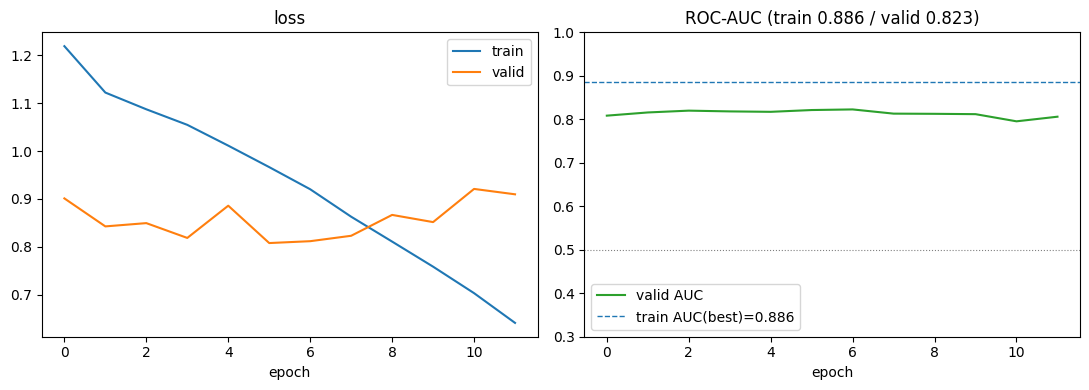

In [5]:
import matplotlib.pyplot as plt

history = result['history']
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history['train_loss'], label="train")
axes[0].plot(history['valid_loss'], label="valid")
axes[0].set_title("loss")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[1].plot(history['valid_auc'], label="valid AUC", color="tab:green")
axes[1].axhline(result['train_auc'], ls="--", c="tab:blue", lw=1, label=f"train AUC(best)={result['train_auc']:.3f}")
axes[1].axhline(0.5, ls=":", c="gray", lw=0.8)
axes[1].set_title(f"ROC-AUC (train {result['train_auc']:.3f} / valid {result['best_auc']:.3f})")
axes[1].set_xlabel("epoch")
axes[1].set_ylim(0.3, 1.0)
axes[1].legend()
plt.tight_layout()
plt.show()


## 4. 신뢰도 추정 - `cross_validate` (k-fold)

데이터가 적으므로(§4.5-1) 고정 test 분할 대신 k-fold 교차검증으로 teacher 성능 신뢰도를 추정한다.

In [6]:
from pm_safeline.utils.training import cross_validate
from pm_safeline.datasets.roadview import PMRoadviewDataset, default_transform, DEFAULT_SEVERITY_WEIGHTS

# 5-fold 교차검증(§4.5-1): 소표본이라 단일 분할 대신 fold 평균±표준편차로 신뢰도 추정.
full_ds = PMRoadviewDataset(transform=default_transform(train=True), severity_weights=DEFAULT_SEVERITY_WEIGHTS)


def build_model_fn():
    return build_pm_risk_vit(PMRiskViTConfig(freeze_backbone=True))


cv_cfg = TrainConfig(epochs=10, lr=1e-4, batch_size=64, patience=3, num_workers=32)
cv_result = cross_validate(build_model_fn, full_ds, n_splits=5, cfg=cv_cfg, pos_weight=pos_weight,
                           checkpoint_dir="../../../checkpoints/cv")
print(f"fold AUCs: {cv_result['fold_aucs']}")
print(f"mean AUC = {cv_result['mean_auc']:.4f} ± {cv_result['std_auc']:.4f}")


[cross_validate] fold 1/5


[train_teacher] epoch 1/10 train_loss=1.2036 valid_loss=0.8895 valid_auc=0.8153


[save_checkpoint] 저장: ../../../checkpoints/cv/fold1.pt


[train_teacher] epoch 2/10 train_loss=1.1209 valid_loss=0.9124 valid_auc=0.8163


[save_checkpoint] 저장: ../../../checkpoints/cv/fold1.pt


...

[save_checkpoint] 저장: ../../../checkpoints/cv/fold5.pt


[train_teacher] epoch 9/10 train_loss=0.8259 valid_loss=0.8434 valid_auc=0.8018


[save_checkpoint] 저장: ../../../checkpoints/cv/fold5.pt


[train_teacher] epoch 10/10 train_loss=0.7717 valid_loss=0.8772 valid_auc=0.7979


fold AUCs: [0.8237325305799985, 0.8017998989810899, 0.7879645325513451, 0.7990787386713801, 0.8017755635472481]
mean AUC = 0.8029 ± 0.0116


## 5. 보정 - `calibrate` (temperature scaling)

ViT teacher 는 소량 데이터에서 과신(overconfident)하기 쉽다(§4.5). valid set 으로 온도 T 를 학습해
확률 보정을 적용한다.

In [7]:
from pm_safeline.utils.training import calibrate

model.load_state_dict(result['best_state'])
calibrator = calibrate(model, valid_ds, cfg, method="temperature")
print(f"temperature = {calibrator.temperature:.4f}")

[calibrate] temperature=1.1944
temperature = 1.1944


## 6. 체크포인트 저장 - `save_checkpoint`

In [8]:
from pathlib import Path

from pm_safeline.utils.training import save_checkpoint

ckpt_path = Path("../../../checkpoints/pm_risk_vit_teacher.pt")
save_checkpoint(
    model,
    ckpt_path,
    extra={
        'config': model.config.to_dict(),
        'temperature': calibrator.temperature,
        'best_valid_auc': result['best_auc'],
        'cv_mean_auc': cv_result['mean_auc'],
    },
)
print(f"저장: {ckpt_path}")

[save_checkpoint] 저장: ../../../checkpoints/pm_risk_vit_teacher.pt
저장: ../../../checkpoints/pm_risk_vit_teacher.pt
